In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import sys

import sympy

sys.path.append('//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses')
sys.path.append('//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy')

# in pycode folder, includes all the langevin-regression code implemented for 2d
import langevin_sindy as lg
import timecorr as tc
import fp_solvers as fps

# phase plane analysis code
import utils.pplane as pplane

# Euler-Maruyama for stochastic simulation of trajectories
from utils.stochastic_sim import stochastic_sim_EM

JEPA dataset info: 
- columns 0-255 are the latent features of the model
- T is the index of the timepoint (0 to 576, units 5 minutes)
- features over time for each of 54 image crops

Original endothelial cell dataset info (from `cellsmap/cellsmap/config.yaml`):
- flow rate of 20 dyn/cm^2 from 0 to 24 hours
- flow rate of 6 dyn/cm^2 from 24 to 48 hours
- time interval between images (data points) is 5 minutes

Data loaded and preprocessed in `utils/jepa_feats_init.py`.

In [9]:
exp_var = np.load('../data/JEPA_ExpVar.npy')
pcs = np.load('../data/JEPA_PCs.npy')

num_modes_95 = np.where(np.cumsum(exp_var) > 0.95)[0].min()
print("Number of modes to explain 95% of variance: ", num_modes_95)

Number of modes to explain 95% of variance:  2


In [10]:
X_t = np.load('../data/JEPA_95pctVarPCs_all.npy') # preprocessed data: num_loc * num_timepoints * num_modes_95 array

X_t_high = np.load('../data/JEPA_95pctVarPCs_highFlow.npy')
X_t_low = np.load('../data/JEPA_95pctVarPCs_lowFlow.npy')

num_loc = X_t.shape[0]
num_t = X_t.shape[1]
t_change = (24*60 - 25)//5 # time point (frame number) at which to change from high to low flow occurs (25 minutes before 24 hours)

Text(0, 0.5, 'PC1')

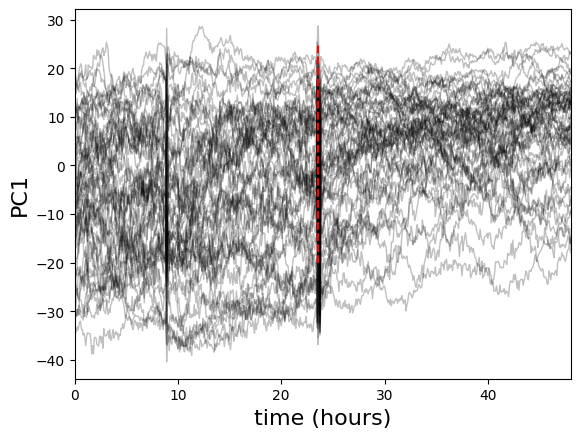

In [16]:
# plot top PCA mode vs time for each location at high flow
for i in range(num_loc):
    plt.plot(5*np.arange(num_t)/60,X_t[i,:,0],'k-',alpha=0.25,linewidth=1)
plt.xlim([0,(num_t)*5//60])
plt.vlines(5*t_change/60,-20,25,color='r',linestyles='dashed')
#plt.vlines(530/60,-20,25,color='b',linestyles='dashed')
plt.xlabel("time (hours)", fontsize=16)
plt.ylabel("PC1", fontsize=16)

Text(0, 0.5, 'PC2')

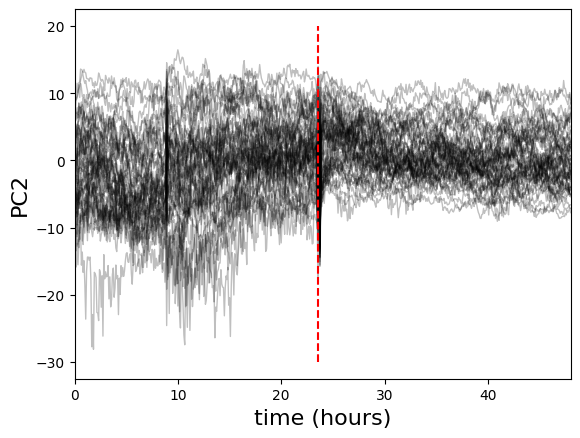

In [15]:
# plot 2nd PCA mode vs time for each location at high flow
for i in range(num_loc):
    plt.plot(5*np.arange(num_t)/60,X_t[i,:,1],'k-',alpha=0.25,linewidth=1)
plt.xlim([0,(num_t)*5//60])
plt.vlines(5*t_change/60,-30,20,color='r',linestyles='dashed')
#plt.vlines(530/60,-20,25,color='b',linestyles='dashed')
plt.xlabel("time (hours)", fontsize=16)
plt.ylabel("PC2", fontsize=16)

Text(0, 0.5, 'PC2')

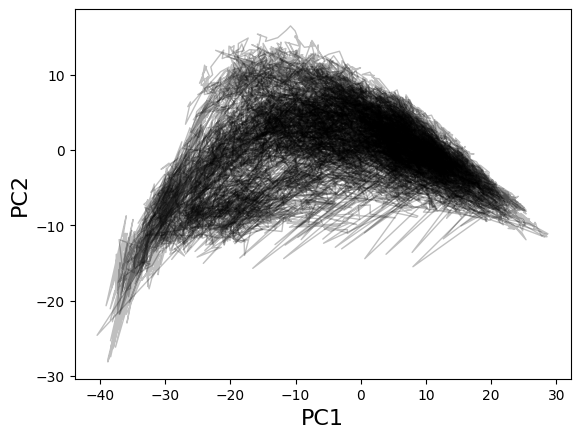

In [14]:
for i in range(num_loc):
    plt.plot(X_t[i,:,0],X_t[i,:,1],'k-',alpha=0.25,linewidth=1)
#plt.xlim([0,(num_t)*5])
plt.xlabel("PC1", fontsize=16)
plt.ylabel("PC2", fontsize=16)

## Langevin regression (1D)

### High flow trajectories

//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:45: RuntimeWarning: Mean of empty slice
  f_KM = np.nanmean(f_KM,axis=1)
//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:46: RuntimeWarning: Mean of empty slice
  a_KM = np.nanmean(a_KM,axis=1)
//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:47: RuntimeWarning: Mean of empty slice
  f_err = np.nanmean(f_err,axis=1)
//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py:48: RuntimeWarning: Mean of empty slice
  a_err = np.nanmean(a_err,axis=1)


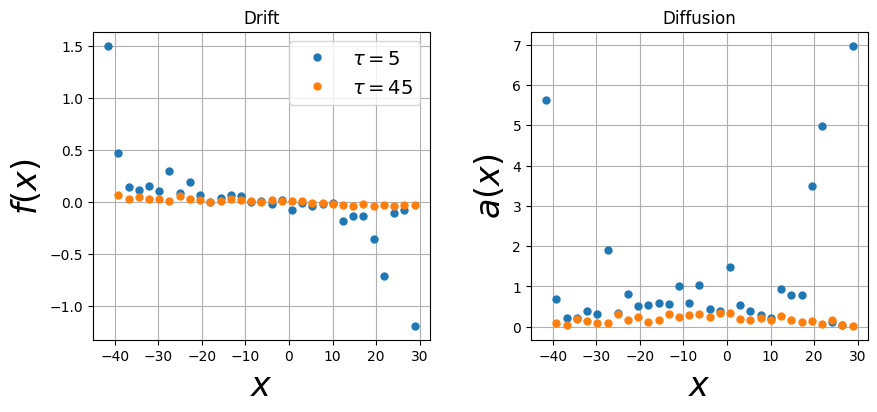

In [21]:
# Langevin regression on first PC mode

# Plot truth, fast sampling, slow sampling

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']

N = 32 # Number of bins
bins = np.linspace(-45,30, N+1)
dx = bins[1]-bins[0]
centers = (bins[:-1]+bins[1:])/2

data = [X_t_high[i,:,0] for i in range(num_loc)] # high flow data, pass as list into KM_avg
dt=5

f_fine, a_fine, _,_ = lg.KM_avg(data, bins, stride=1, dt=dt, multi_traj=True)
stride_coarse=9
f_coarse, a_coarse, _,_ = lg.KM_avg(data, bins, stride=stride_coarse, dt=dt,multi_traj=True)

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.plot(centers, f_fine, '.', markersize=10, c=colors[0], label=r'$\tau=$'+str(np.round(dt,2)))
plt.plot(centers, f_coarse, '.', markersize=10, c=colors[1], label=r'$\tau=$'+str(np.round(dt*stride_coarse,2)))
plt.legend(fontsize=14)
plt.title('Drift')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$f(x)$', fontsize = 24)
plt.grid()

plt.subplot(122)
plt.plot(centers, a_fine, '.', c=colors[0], markersize=10)
plt.plot(centers, a_coarse, '.', c=colors[1], markersize=10)
plt.title('Diffusion')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$a(x)$', fontsize = 24)
plt.grid()

plt.subplots_adjust(wspace=0.3)
plt.show()

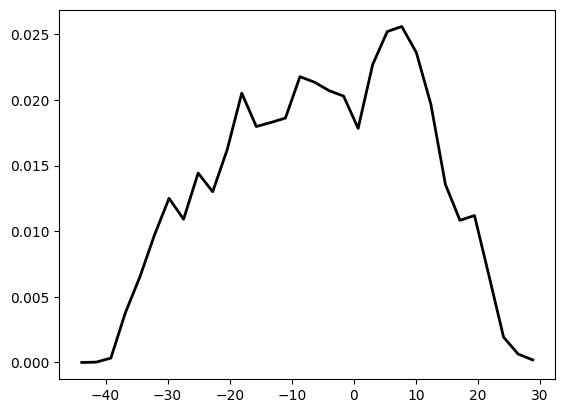

In [22]:
# PDF of states

p_hist = np.histogram(np.concatenate(data), bins, density=True)[0]
plt.plot(centers, p_hist, 'k', lw=2)

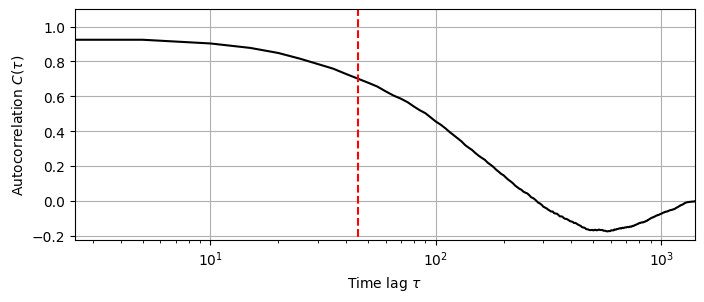

In [23]:
tau = dt*np.arange(0, len(data[0]))
acf = np.zeros(len(tau))
for loc_idx in range(num_loc):
    acf = acf + tc.autocorr_func_1d(data[loc_idx])
acf = acf/num_loc

plt.figure(figsize=(8, 3))
plt.plot(tau, acf, 'k')

plt.ylabel(r'Autocorrelation $C(\tau)$')
plt.xlabel(r'Time lag $\tau$')
plt.vlines(stride_coarse*dt, -0.6, 1.1, 'r', '--')

plt.ylim([acf.min()-0.05, 1.1])
plt.xlim([0.5*dt, tau.max()])
plt.gca().set_xscale('log')

plt.grid()
plt.show()


/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/.venv/lib/python3.10/site-packages/numpy/lib/histograms.py:1067: RuntimeWarning: invalid value encountered in divide
  hist /= s
/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/.venv/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


/tmp/ipykernel_927/2238632850.py:6: RuntimeWarning: Mean of empty slice
  kl_div = np.nanmean(kl_div,axis=0)


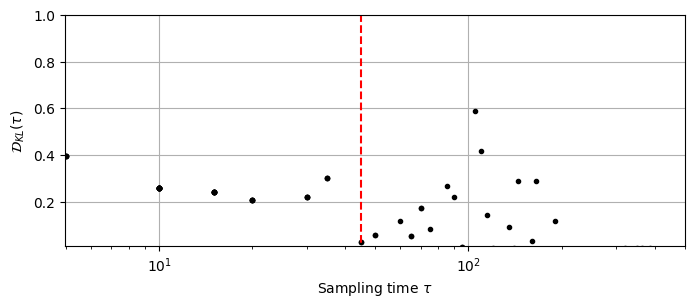

In [24]:
# Markov test
lag = np.round( np.logspace(0.1, 2, 100) ).astype(int)
kl_div = np.zeros((num_loc,len(lag)))
for loc_idx in range(num_loc):
    kl_div[loc_idx,:] = np.array([tc.markov_test(data[loc_idx], delta, N=32) for delta in lag])
kl_div = np.nanmean(kl_div,axis=0)

plt.figure(figsize=(8, 3))
plt.gca().set_xscale('log')
plt.plot(dt*lag, kl_div, 'k.')
plt.vlines(dt*stride_coarse, -0.3, 1.2, 'r', '--')

plt.ylabel(r'$\mathcal{D}_{KL}(\tau)$')
plt.xlabel(r'Sampling time $\tau$')
plt.xlim([dt*lag.min()-0.05, dt*lag.max()+0.05])
plt.ylim([1e-2, np.max([np.nanmax(kl_div)+0.05,1])])
plt.grid()

In [25]:
## Kramers-Moyal average
stride = stride_coarse
f_KM, a_KM, f_err, a_err = lg.KM_avg(data, bins, stride=stride, dt=dt, multi_traj=True)

In [26]:
### Build SINDy libraries with sympy
x = sympy.symbols('x')

f_expr = np.array([x**i for i in np.arange(5)])  # Polynomial library for drift
s_expr = np.array([x**i for i in np.arange(4)])  # Polynomial library for diffusion

# Convert sympy expressions into library matrices
lib_f = np.zeros([len(f_expr), N])
for k in range(len(f_expr)):
    lamb_expr = sympy.lambdify(x, f_expr[k])
    lib_f[k] = lamb_expr(centers)

lib_f = lib_f.T

lib_s = np.zeros([len(s_expr), N])
for k in range(len(s_expr)):
    lamb_expr = sympy.lambdify(x, s_expr[k])
    lib_s[k] = lamb_expr(centers)

lib_s = lib_s.T

In [27]:
# Initialize Xi with least squares regression (no finite-time corrections)

Xi0 = np.zeros((len(f_expr) + len(s_expr)))
mask = np.nonzero(np.isfinite(f_KM))[0]
Xi0[:len(f_expr)] = np.linalg.lstsq( lib_f[mask], f_KM[mask], rcond=None)[0]   # Regression against drift
Xi0[len(f_expr):] = np.linalg.lstsq( lib_s[mask], np.sqrt(2*a_KM[mask]), rcond=None)[0]  # Regression against diffusion

print(Xi0)

[ 5.17060909e-03 -1.66246714e-03 -4.75585791e-05  8.15401213e-07
  4.53651604e-08  7.18276829e-01 -2.99993235e-03 -3.82547810e-04
 -2.22385361e-06]


In [35]:
### Weights: uncertainties in Kramers-Moyal
# This is helpful, but not that critical.  The specific choice of weights doesn't matter that much
W = np.array((f_err.flatten(), a_err.flatten()))
W[np.less(abs(W), 1e-12, where=np.isfinite(W))] = 1e6  # Set zero entries to large weights
W[np.logical_not(np.isfinite(W))] = 1e6                 # Set NaN entries to large numbers (small weights)
W = 1/W  # Invert error for weights
W = W/np.nansum(W.flatten())

# Compute empirical PDF
p_hist = np.histogram(np.concatenate(data), bins, density=True)[0]

# Initialize adjoint solver
afp = fps.AdjFP(centers)

# Initialize forward steady-state solver
fp = fps.SteadyFP(N, dx)

# Optimization parameters
params = {"W": W, "f_KM": f_KM, "a_KM": a_KM, "Xi0": Xi0,
          "f_expr": f_expr, "s_expr": s_expr,
          "lib_f": lib_f, "lib_s": lib_s, "N": N,
          "kl_reg": 10,
          "fp": fp, "afp": afp, "p_hist": p_hist, "tau": stride*dt,
          "radial": False}

# Use anonymous function to automatically pass the cost function
opt_fun = lambda params: lg.AFP_opt(lg.cost, params)
Xi, V = lg.SSR_loop(opt_fun, params)

%%%% Optimization time: 2.9593682289123535 seconds,   Cost: 0.07470602570083038 %%%%
[1 2 3 4]
[0 1 2 3]
[x x**2 x**3 x**4] [1 x x**2 x**3]
%%%% Optimization time: 3.5639970302581787 seconds,   Cost: 0.05821147389447161 %%%%
[0 2 3 4]
[0 1 2 3]
[1 x**2 x**3 x**4] [1 x x**2 x**3]
%%%% Optimization time: 3.5781500339508057 seconds,   Cost: 0.23412561840997198 %%%%
[0 1 3 4]
[0 1 2 3]
[1 x x**3 x**4] [1 x x**2 x**3]
%%%% Optimization time: 3.336095094680786 seconds,   Cost: 0.11850610173126123 %%%%
[0 1 2 4]
[0 1 2 3]
[1 x x**2 x**4] [1 x x**2 x**3]
%%%% Optimization time: 3.4754505157470703 seconds,   Cost: 0.07540042030008545 %%%%
[0 1 2 3]
[0 1 2 3]
[1 x x**2 x**3] [1 x x**2 x**3]


In [ ]:
f_vals.s

In [31]:
(afp.ndim, np.prod(afp.N))

(1, 32)

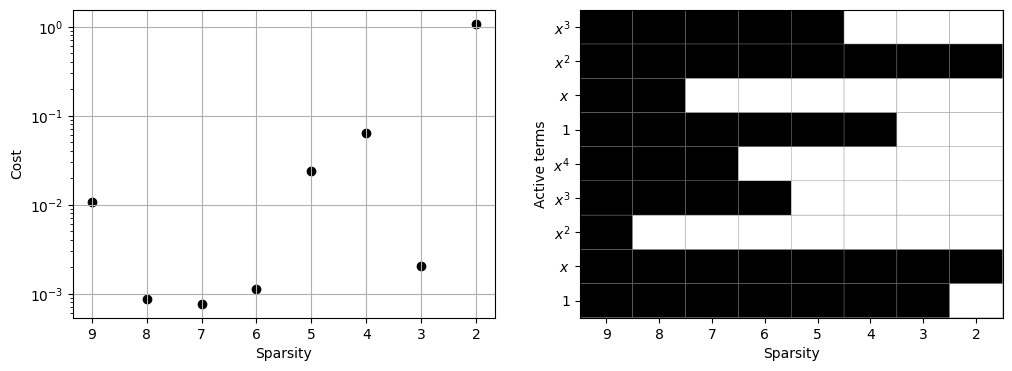

In [ ]:
####################
# SSR cost function
####################

labels = [r'${0}$'.format(sympy.latex(t)) for t in np.concatenate((f_expr, s_expr))]

active = abs(Xi) > 1e-8

n_terms = len(labels)
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.scatter(np.arange(len(V)), V, c='k')

plt.gca().set_xticks(np.arange(n_terms-1))
plt.gca().set_xticklabels(np.arange(n_terms, 1, -1))
plt.xlabel('Sparsity')
plt.ylabel(r'Cost')
plt.gca().set_yscale('log')
plt.grid()

plt.subplot(122)
plt.pcolor(active, cmap='bone_r', edgecolors='gray')
plt.gca().set_yticks(0.5+np.arange(n_terms))
plt.gca().set_yticklabels(labels)
plt.gca().set_xticks(0.5+np.arange(n_terms-1))
plt.gca().set_xticklabels(np.arange(n_terms, 1, -1))
plt.xlabel('Sparsity')
plt.ylabel('Active terms')
plt.show()

In [ ]:
# Select model with the fewest terms before the cost function spikes
n_terms = 6
print("Optimal sparsity: ", n_terms)
print("Cost at optimal sparsity: ", V[1-n_terms])
Xi_f = Xi[:len(f_expr), 1-n_terms]
Xi_s = Xi[len(f_expr):, 1-n_terms]
print("Basis functions (drift): ", f_expr)
print("SINDy expression (drift): ", ["{:0.3E}".format(x) if x!=0 else str(0) for x in Xi_f])
print("Base functions (diffusion): ", s_expr)
print("SINDy expression (diffusion): ", ["{:0.3E}".format(x) if x!=0 else str(0) for x in Xi_s])

# Functions from the expressions
f_sindy_high = sympy.lambdify(x, lg.sindy_model(Xi_f, f_expr))
a_sindy_high = sympy.lambdify(x, 0.5*lg.sindy_model(Xi_s, s_expr)**2)

Optimal sparsity:  6
Cost at optimal sparsity:  0.0011386046443450349
Basis functions (drift):  [1 x x**2 x**3 x**4]
SINDy expression (drift):  ['-7.039E-02', '-9.833E-03', '0', '1.348E-05', '0']
Base functions (diffusion):  [1 x x**2 x**3]
SINDy expression (diffusion):  ['7.835E-01', '0', '-3.220E-03', '-7.263E-05']


In [ ]:
f_vals = f_sindy_high(centers)
a_vals = a_sindy_high(centers)

# Check if a scalar (happens when library is a constant)
if np.isscalar(a_vals):
    a_vals = a_vals + 0*centers
if np.isscalar(f_vals):
    f_vals = f_vals + 0*centers

KL divergence (LINDy model): -0.00803


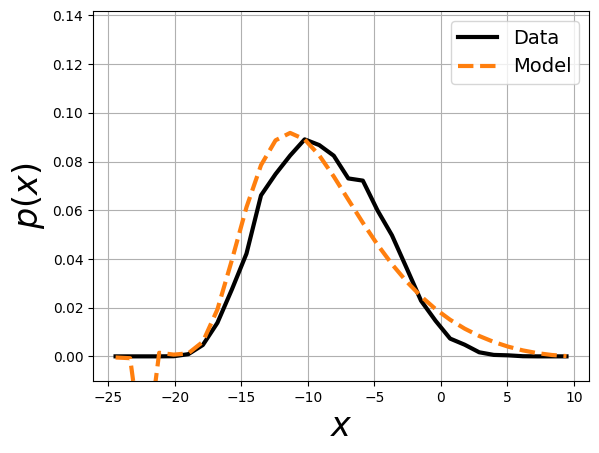

In [ ]:
# Compare PDFs: empirical vs Fokker-Planck solution with model

p_fit = fp.solve(f_vals, a_vals)
print('KL divergence (LINDy model): {0:0.5f}'.format(tc.kl_divergence(p_hist, p_fit, dx=dx, tol=1e-6)))

#plt.figure(figsize=(4, 2))
plt.plot(centers, p_hist, 'k', label='Data', lw=3)
plt.plot(centers, p_fit, '--', c=colors[1], label='Model', lw=3)
plt.legend(fontsize=14)
#plt.gca().set_yscale('log')
plt.ylim([-1e-2, np.max([p_hist.max()+0.05, p_fit.max()+0.05])])
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$p(x)$', fontsize = 24)
plt.grid()

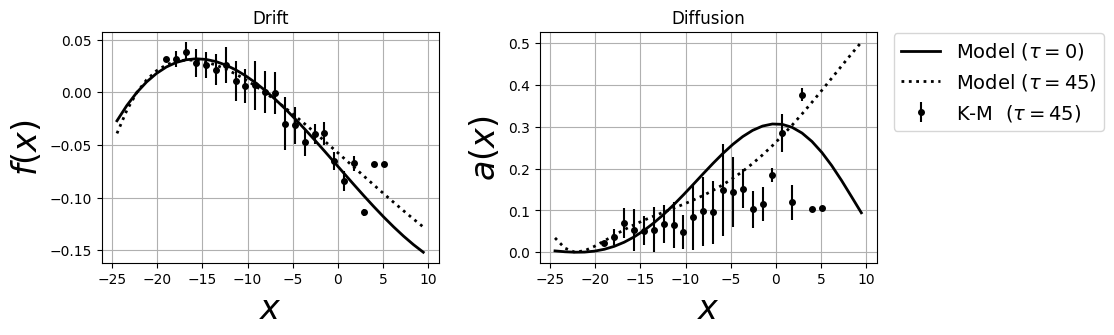

In [ ]:
afp.precompute_operator(f_vals, a_vals)
f_tau, a_tau = afp.solve(stride*dt)

plt.figure(figsize=(10, 3))
plt.subplot(121)
plt.errorbar(centers, f_KM, f_err, ls='', marker='.', markersize=8, 
             c='k')
plt.plot(centers, f_vals, 'k', lw=2)
plt.plot(centers, f_tau, 'k:', lw=2)
plt.title('Drift')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$f(x)$', fontsize = 24)
plt.grid()
#plt.xlim([-1.8, 1.8])
#plt.ylim([-1, 0.3])


plt.subplot(122)
plt.errorbar(centers, a_KM, a_err, ls='', marker='.', markersize=8, 
             c='k', label=r'K-M  ($\tau =$'+str(np.round(stride*dt,2))+')')
plt.plot(centers, a_vals, 'k', lw=2, label=r'Model ($\tau = 0$)')
plt.plot(centers, a_tau, 'k:', lw=2, label=r'Model ($\tau =$'+str(np.round(stride*dt,2))+')')
plt.legend(fontsize=14,loc=(1.05,0.57))
plt.title('Diffusion')
plt.xlabel('$x$', fontsize = 24)
plt.ylabel('$a(x)$', fontsize = 24)
plt.grid()
# plt.xlim([-1.8, 1.8])
#plt.ylim([0, 1.25])

plt.subplots_adjust(wspace=0.3)
plt.show()

/tmp/ipykernel_892/67012155.py:11: RuntimeWarning: invalid value encountered in log
  lnP = -np.log(p_fit)


Text(0.5, 0, '$x$')

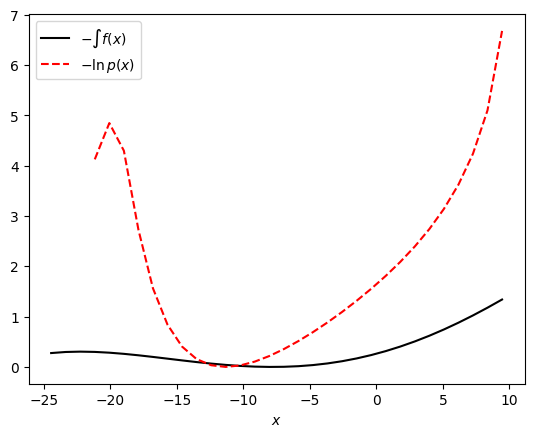

In [ ]:
def U(x):
    h=0.1
    num = np.round((x-bins[0])/h).astype(int)
    xvec = np.linspace(bins[0],x,num)
    return -np.trapz(f_sindy_high(xvec), xvec)

Uvec = np.zeros(centers.shape[0])
for i in range(centers.shape[0]):
    Uvec[i] = U(centers[i])

lnP = -np.log(p_fit)
plt.plot(centers, Uvec-Uvec.min(), 'k-',label='$-\\int f(x)$')
plt.plot(centers, lnP-np.nanmin(lnP), 'r--',label='$-\\ln p(x)$')
plt.legend()
plt.xlabel('$x$')

In [ ]:
inits_idx = np.random.choice(np.arange(num_loc),size=20)
inits = X_t_high[inits_idx,0,0]

traj_model = stochastic_sim_EM(inits[:,None], f_sindy_high, lambda x: np.sqrt(2*a_sindy_high(x)), t_change, dt)[:,:,0]

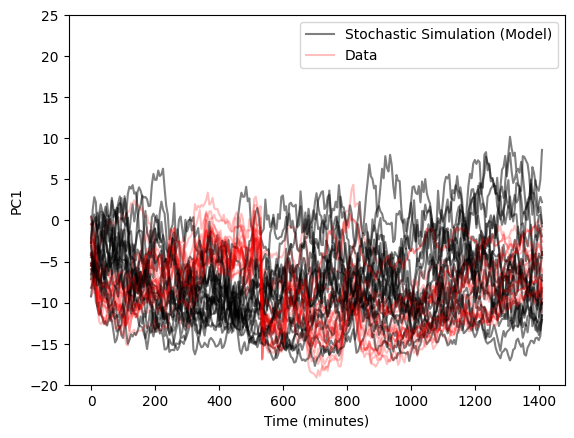

In [ ]:
for i in range(len(inits)):
    plt.plot(np.arange(t_change)*dt,traj_model[i,:],'k-',alpha=0.5)
    plt.plot(np.arange(t_change)*dt,X_t_high[inits_idx[i],:,0],'r-',alpha=0.25)

plt.ylim([-20,25])
plt.xlabel('Time (minutes)')
plt.ylabel('PC1')
plt.legend(['Stochastic Simulation (Model)','Data'])